# Algorithmic Trading Strategy


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from IPython.display import Image, display
import pandas_ta as ta
import warnings

In [2]:
warnings.filterwarnings('ignore')

#### User Defined Function
List of functions that will be used in this notebook

In [3]:
# A function to download the data and standardize it into a desire format
def get_data(symbol):
    ticker = yf.Ticker(symbol)
    data = ticker.history(period='max', interval='1d') # in this example I'll use interday (daily timeframe)
    data.reset_index(inplace=True)
    data.columns = [c.lower().replace(' ', '_') for c in data.columns]
    return data

### Download and Check Data

We will use Google stock data from Yahoo Finance

In [4]:
data = get_data('GOOG')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   date          5208 non-null   datetime64[ns, America/New_York]
 1   open          5208 non-null   float64                         
 2   high          5208 non-null   float64                         
 3   low           5208 non-null   float64                         
 4   close         5208 non-null   float64                         
 5   volume        5208 non-null   int64                           
 6   dividends     5208 non-null   float64                         
 7   stock_splits  5208 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 325.6 KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
open,5208.0,4.965948e+01,4.869257e+01,2.458844,1.312577e+01,2.796317e+01,6.712581e+01,2.042673e+02
high,5208.0,5.019155e+01,4.924506e+01,2.522057,1.327550e+01,2.819017e+01,6.767185e+01,2.084625e+02
low,5208.0,4.915422e+01,4.819271e+01,2.378775,1.299582e+01,2.771698e+01,6.659109e+01,2.040275e+02
close,5208.0,4.967971e+01,4.871956e+01,2.479171,1.312881e+01,2.788793e+01,6.711735e+01,2.074736e+02
volume,5208.0,1.122896e+08,1.481586e+08,158434.000000,2.638895e+07,5.106000e+07,1.368229e+08,1.650833e+09
dividends,5208.0,1.536098e-04,5.541143e-03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01
stock_splits,5208.0,4.417194e-03,2.788602e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01


In [7]:
data.head()

,date,open,high,low,close,volume,dividends,stock_splits
0,2004-08-19 00:00:00-04:00,2.478923,2.579567,2.378775,2.487352,897427216,0.0,0.0
1,2004-08-20 00:00:00-04:00,2.503960,2.704009,2.491318,2.684922,458857488,0.0,0.0
2,2004-08-23 00:00:00-04:00,2.745408,2.813082,2.703266,2.711942,366857939,0.0,0.0
3,2004-08-24 00:00:00-04:00,2.757554,2.766478,2.567421,2.599647,306396159,0.0,0.0
4,2004-08-25 00:00:00-04:00,2.601877,2.677238,2.575105,2.627658,184645512,0.0,0.0


In [8]:
print(data.date.min())
print(data.date.max())

2004-08-19 00:00:00-04:00
2025-04-30 00:00:00-04:00


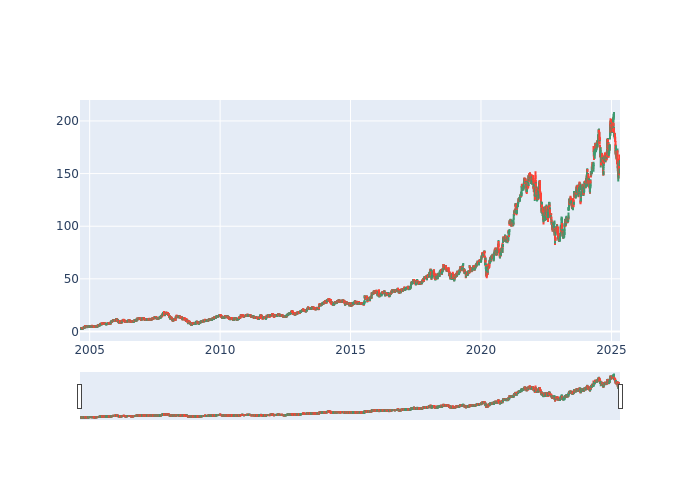

In [10]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=data.date,
    open=data.open,
    high=data.high,
    low=data.low,
    close=data.close,
    name='OHLC'
))

fig.write_image("./assets/plot1.png")  
display(Image("./assets/plot1.png"))

# Uncomment below fig for interactive plot in your local
# fig.show() 

**Summary**: The Google stock data obtained from Yahoo Finance consists of 5,208 records, with no missing values found in any of the columns. The data covers the period from August 2004 to April 2025.

### Market Trend

The market trend is essentially a general direction in which the price of a financial asset is moving over a period of time. It can be either upward (bullish) or downward (bearish). <br/>
In this notebook we will use Moving Average (MA) and Average Directional Index (ADX) to detect the trend.

#### Market Trend - Moving Average

MA is a fundamental trend indicator used to smooth out price data and identify trend over a specified period of time

In [14]:
# We will compute and plot 2 types of MA in this example,
# one is for 5 days window of the closing price another for 30 days window of the closing price

data['ma_5'] = data['close'].rolling(window=5).mean()
data['ma_30'] = data['close'].rolling(window=30).mean()

In [12]:
data.head(7)

,date,open,high,low,close,volume,dividends,stock_splits,ma_5,ma_30
0,2004-08-19 00:00:00-04:00,2.478923,2.579567,2.378775,2.487352,897427216,0.0,0.0,NaN,NaN
1,2004-08-20 00:00:00-04:00,2.503960,2.704009,2.491318,2.684922,458857488,0.0,0.0,NaN,NaN
2,2004-08-23 00:00:00-04:00,2.745408,2.813082,2.703266,2.711942,366857939,0.0,0.0,NaN,NaN
3,2004-08-24 00:00:00-04:00,2.757554,2.766478,2.567421,2.599647,306396159,0.0,0.0,NaN,NaN
4,2004-08-25 00:00:00-04:00,2.601877,2.677238,2.575105,2.627658,184645512,0.0,0.0,2.622304,NaN
5,2004-08-26 00:00:00-04:00,2.601630,2.675998,2.594441,2.675006,142572401,0.0,0.0,2.659835,NaN
6,2004-08-27 00:00:00-04:00,2.679716,2.692606,2.619974,2.631377,124826132,0.0,0.0,2.649126,NaN


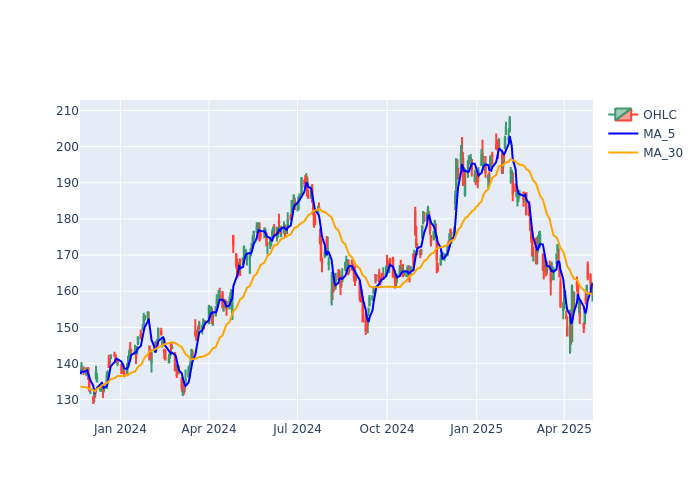

In [13]:
# Visualize the MA along with the candle for last 360 days
df = data.sort_values(by='date', ascending=False)[:360]

fig = go.Figure()
fig.add_trace(go.Candlestick(
    x=df.date,
    open=df.open,
    high=df.high,
    low=df.low,
    close=df.close,
    name='OHLC'
))

fig.add_trace(
    go.Scatter(
        x=df.date,
        y=df.ma_5,
        mode='lines',
        line=dict(color='blue', width=2),
        name='MA_5'
    )
)

fig.add_trace(
    go.Scatter(
        x=df.date,
        y=df.ma_30,
        mode='lines',
        line=dict(color='orange', width=2), 
        name='MA_30'
    )
)

fig.update_layout(
    xaxis=dict(rangeslider=dict(visible=False))
)

fig.write_image("./assets/plot2.png")  
display(Image("./assets/plot2.png"))

# Uncomment below fig for interactive plot in your local
# fig.show() 